# 00 — Preparação da referência geográfica do IBGE

## Objetivo

Este notebook prepara e valida uma dimensão geográfica municipal de referência
a partir dos dados integrados do IBGE.

A referência resultante será reutilizada em diferentes sistemas de informação
em saúde, incluindo SINAN, SIH e SIM, permitindo padronizar informações
geográficas e contextuais utilizadas nas etapas de integração.

As principais verificações realizadas incluem:

- estrutura e tipos das variáveis;
- unicidade dos códigos municipais;
- ausência de códigos;
- ausência de Unidade Federativa;
- ausência de região;
- ausência de população;
- ausência de coordenadas;
- ausência de PIB per capita;
- coerência entre código municipal e Unidade Federativa;
- identificação de municípios com informações incompletas.

Ao final, será gerada uma dimensão municipal validada para uso nas demais
etapas do pipeline.

## 1 - Montagem do drive

In [5]:
from google.colab import drive
import os

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##2 - Imports

In [6]:
import pandas as pd
import numpy as np

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 3. Configuração dos caminhos

In [7]:
# ============================================================
# CONFIGURAÇÃO
# ============================================================

PASTA_BASE = Path(
    "/content/drive/MyDrive/Doutorado/arbovirus_rag"
)

PASTA_REFERENCIA = (
    PASTA_BASE
    / "data_reference"
    / "IBGE"
)

PASTA_REFERENCIA.mkdir(
    parents=True,
    exist_ok=True
)

ARQUIVO_IBGE = (
    PASTA_REFERENCIA
    / "municipios_populacao_2022.parquet"
)

print("Arquivo de referência:")
print(ARQUIVO_IBGE)

Arquivo de referência:
/content/drive/MyDrive/Doutorado/arbovirus_rag/data_reference/IBGE/municipios_populacao_2022.parquet


## 4 Agora precisamos da base municipal do IBGE

Você já havia construído anteriormente um dataframe chamado: municipios_pop

com esta estrutura:

Codigo_Municipio_7

Codigo_Municipio_6

Municipio

Populacao

UF

Regiao

Para não depender de executar outro notebook toda vez, o ideal é salvar essa base como uma base de referência reutilizável.

Estrutura:

arbovirus_rag/

│

├── data_raw/

├── data_processed/

├── data_docs/

└── data_reference/ └── IBGE/ └── municipios_populacao_2022.parquet

In [8]:
import pandas as pd
import requests

# ============================================================
# 1. BASE DE LOCALIDADES DO IBGE
# ============================================================
url_localidades = "https://servicodados.ibge.gov.br/api/v1/localidades/municipios"
municipios = pd.read_json(url_localidades)

def get_nested_value(data_dict, *keys):
    if not isinstance(data_dict, dict):
        return None
    for key in keys:
        data_dict = data_dict.get(key)
    return data_dict

df_final = pd.DataFrame({
    "Codigo_Municipio_7": municipios["id"].astype(str),
    "Nome_Municipio": municipios["nome"],
    "UF": municipios["microrregiao"].apply(lambda x: get_nested_value(x, "mesorregiao", "UF", "sigla")),
    "Codigo_UF": municipios["microrregiao"].apply(lambda x: get_nested_value(x, "mesorregiao", "UF", "id")),
    "Regiao": municipios["microrregiao"].apply(lambda x: get_nested_value(x, "mesorregiao", "UF", "regiao", "nome"))
})

# Cria chave de 6 dígitos compatível com o SINAN
df_final["Codigo_Municipio_6"] = df_final["Codigo_Municipio_7"].str[:6]


# ============================================================
# 2. POPULAÇÃO (CENSO 2022 - Tabela 9514)
# ============================================================
url_pop = "https://apisidra.ibge.gov.br/values/t/9514/n6/all/v/93/p/2022"
pop_raw = pd.read_json(url_pop)
df_pop = pop_raw.iloc[1:][["D1C", "V"]].copy()
df_pop.columns = ["Codigo_Municipio_7", "Populacao_2022"]
df_pop["Codigo_Municipio_7"] = df_pop["Codigo_Municipio_7"].astype(str)
df_pop["Populacao_2022"] = pd.to_numeric(df_pop["Populacao_2022"], errors="coerce")

df_final = df_final.merge(df_pop, on="Codigo_Municipio_7", how="left")


# ============================================================
# 3. DADOS GEOESPACIAIS (LATITUDE, LONGITUDE E CAPITAL)
# ============================================================
# Base aberta oficial georreferenciada dos municípios brasileiros
url_geo = "https://raw.githubusercontent.com/kelvins/Municipios-Brasileiros/main/csv/municipios.csv"
df_geo = pd.read_csv(url_geo)
df_geo = df_geo[["codigo_ibge", "latitude", "longitude", "capital"]].copy()
df_geo.columns = ["Codigo_Municipio_7", "Latitude", "Longitude", "Is_Capital"]
df_geo["Codigo_Municipio_7"] = df_geo["Codigo_Municipio_7"].round().astype(str)

df_final = df_final.merge(df_geo, on="Codigo_Municipio_7", how="left")


# ============================================================
# 4. PIB PER CAPITA (Ano explícito: 2021)
# ============================================================
try:
    url_pib = "https://apisidra.ibge.gov.br/values/t/5938/n6/all/v/543/p/2021"
    pib_raw = pd.read_json(url_pib)
    df_pib = pib_raw.iloc[1:][["D1C", "V"]].copy()
    df_pib.columns = ["Codigo_Municipio_7", "PIB_per_capita_2021"]
    df_pib["Codigo_Municipio_7"] = df_pib["Codigo_Municipio_7"].astype(str)
    df_pib["PIB_per_capita_2021"] = pd.to_numeric(df_pib["PIB_per_capita_2021"], errors="coerce")
    df_final = df_final.merge(df_pib, on="Codigo_Municipio_7", how="left")
except Exception as e:
    print(f"Não foi possível carregar o PIB via API: {e}")


# ============================================================
# 5. VISUALIZAÇÃO DOS RESULTADOS
# ============================================================
df_final.head()

,Codigo_Municipio_7,Nome_Municipio,UF,Codigo_UF,Regiao,Codigo_Municipio_6,Populacao_2022,Latitude,Longitude,Is_Capital,PIB_per_capita_2021
0,1100015,Alta Floresta D'Oeste,RO,11.0,Norte,110001,21494.0,-11.92830,-61.9953,0,49597.0
1,1100023,Ariquemes,RO,11.0,Norte,110002,96833.0,-9.90571,-63.0325,0,420336.0
2,1100031,Cabixi,RO,11.0,Norte,110003,5351.0,-13.49450,-60.5520,0,11193.0
3,1100049,Cacoal,RO,11.0,Norte,110004,86887.0,-11.43430,-61.4562,0,384627.0
4,1100056,Cerejeiras,RO,11.0,Norte,110005,15890.0,-13.18700,-60.8168,0,131906.0


Salvando o arquivo na pasta:

In [9]:
# Salva o DataFrame no caminho definido
df_final.to_parquet(ARQUIVO_IBGE, index=False)

print(f"Arquivo salvo com sucesso em: {ARQUIVO_IBGE}")

Arquivo salvo com sucesso em: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_reference/IBGE/municipios_populacao_2022.parquet


## 4. Carregar a referência atual

In [10]:
# ============================================================
# CARREGAMENTO DA REFERÊNCIA
# ============================================================

municipios_ibge = pd.read_parquet(
    ARQUIVO_IBGE
)

print(
    f"Municípios/registros carregados: "
    f"{len(municipios_ibge):,}"
)

print(
    f"Quantidade de variáveis: "
    f"{municipios_ibge.shape[1]}"
)

display(
    municipios_ibge.head()
)

Municípios/registros carregados: 5,571
Quantidade de variáveis: 11


,Codigo_Municipio_7,Nome_Municipio,UF,Codigo_UF,Regiao,Codigo_Municipio_6,Populacao_2022,Latitude,Longitude,Is_Capital,PIB_per_capita_2021
0,1100015,Alta Floresta D'Oeste,RO,11.0,Norte,110001,21494.0,-11.92830,-61.9953,0,49597.0
1,1100023,Ariquemes,RO,11.0,Norte,110002,96833.0,-9.90571,-63.0325,0,420336.0
2,1100031,Cabixi,RO,11.0,Norte,110003,5351.0,-13.49450,-60.5520,0,11193.0
3,1100049,Cacoal,RO,11.0,Norte,110004,86887.0,-11.43430,-61.4562,0,384627.0
4,1100056,Cerejeiras,RO,11.0,Norte,110005,15890.0,-13.18700,-60.8168,0,131906.0


## 5. Verificar estrutura

In [11]:
# ============================================================
# ESTRUTURA DO DATAFRAME
# ============================================================

municipios_ibge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5571 entries, 0 to 5570
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Codigo_Municipio_7   5571 non-null   object 
 1   Nome_Municipio       5571 non-null   object 
 2   UF                   5570 non-null   object 
 3   Codigo_UF            5570 non-null   float64
 4   Regiao               5570 non-null   object 
 5   Codigo_Municipio_6   5571 non-null   object 
 6   Populacao_2022       5570 non-null   float64
 7   Latitude             5571 non-null   float64
 8   Longitude            5571 non-null   float64
 9   Is_Capital           5571 non-null   int64  
 10  PIB_per_capita_2021  5570 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 478.9+ KB


In [12]:
display(
    pd.DataFrame({
        "VARIAVEL": municipios_ibge.columns,
        "TIPO": [
            str(municipios_ibge[coluna].dtype)
            for coluna in municipios_ibge.columns
        ]
    })
)

,VARIAVEL,TIPO
0,Codigo_Municipio_7,object
1,Nome_Municipio,object
2,UF,object
3,Codigo_UF,float64
4,Regiao,object
5,Codigo_Municipio_6,object
6,Populacao_2022,float64
7,Latitude,float64
8,Longitude,float64
9,Is_Capital,int64


## 6. Conferir as colunas esperadas

In [13]:
# ============================================================
# VARIÁVEIS ESPERADAS
# ============================================================

VARIAVEIS_ESPERADAS = [
    "Codigo_Municipio_7",
    "Nome_Municipio",
    "UF",
    "Codigo_UF",
    "Regiao",
    "Codigo_Municipio_6",
    "Populacao_2022",
    "Latitude",
    "Longitude",
    "Is_Capital",
    "PIB_per_capita_2021"
]

inventario = []

for coluna in VARIAVEIS_ESPERADAS:

    inventario.append({
        "VARIAVEL": coluna,
        "EXISTE": coluna in municipios_ibge.columns
    })

display(
    pd.DataFrame(inventario)
)

,VARIAVEL,EXISTE
0,Codigo_Municipio_7,True
1,Nome_Municipio,True
2,UF,True
3,Codigo_UF,True
4,Regiao,True
5,Codigo_Municipio_6,True
6,Populacao_2022,True
7,Latitude,True
8,Longitude,True
9,Is_Capital,True


## 7. Padronizar códigos como identificadores

Evitar int como tipo definitivo para códigos territoriais.

In [14]:
# ============================================================
# PADRONIZAÇÃO DOS CÓDIGOS GEOGRÁFICOS
# ============================================================

municipios_ibge["Codigo_Municipio_6"] = (
    municipios_ibge["Codigo_Municipio_6"]
    .astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(6)
)

municipios_ibge["Codigo_Municipio_7"] = (
    municipios_ibge["Codigo_Municipio_7"]
    .astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(7)
)

municipios_ibge["Codigo_UF"] = (
    municipios_ibge["Codigo_UF"]
    .astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(2)
)

## 8. Verificar códigos inválidos

In [15]:
# ============================================================
# VALIDAÇÃO DO FORMATO DOS CÓDIGOS
# ============================================================

codigo_6_invalido = (
    municipios_ibge["Codigo_Municipio_6"]
    .notna()
    &
    ~municipios_ibge["Codigo_Municipio_6"]
    .str.fullmatch(r"\d{6}")
)

codigo_7_invalido = (
    municipios_ibge["Codigo_Municipio_7"]
    .notna()
    &
    ~municipios_ibge["Codigo_Municipio_7"]
    .str.fullmatch(r"\d{7}")
)

print(
    "Códigos municipais de 6 dígitos inválidos:",
    codigo_6_invalido.sum()
)

print(
    "Códigos municipais de 7 dígitos inválidos:",
    codigo_7_invalido.sum()
)

Códigos municipais de 6 dígitos inválidos: 0
Códigos municipais de 7 dígitos inválidos: 0


## 9. Verificar duplicidades

Essa etapa é essencial porque essa tabela será usada em merge many_to_one.


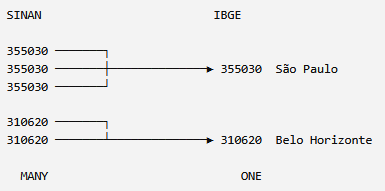

In [16]:
# ============================================================
# DUPLICIDADES DOS CÓDIGOS MUNICIPAIS
# ============================================================

duplicados_6 = (
    municipios_ibge[
        municipios_ibge["Codigo_Municipio_6"]
        .duplicated(keep=False)
    ]
)

duplicados_7 = (
    municipios_ibge[
        municipios_ibge["Codigo_Municipio_7"]
        .duplicated(keep=False)
    ]
)

print(
    "Registros envolvidos em duplicidades "
    "do código de 6 dígitos:",
    len(duplicados_6)
)

print(
    "Registros envolvidos em duplicidades "
    "do código de 7 dígitos:",
    len(duplicados_7)
)

Registros envolvidos em duplicidades do código de 6 dígitos: 0
Registros envolvidos em duplicidades do código de 7 dígitos: 0


Se o resultado for diferente de zero:

In [17]:
display(
    duplicados_6.sort_values(
        "Codigo_Municipio_6"
    )
)

,Codigo_Municipio_7,Nome_Municipio,UF,Codigo_UF,Regiao,Codigo_Municipio_6,Populacao_2022,Latitude,Longitude,Is_Capital,PIB_per_capita_2021


Não remova duplicidades automaticamente ainda.

## 10. Avaliar completude

In [18]:
# ============================================================
# COMPLETUDE DA REFERÊNCIA IBGE
# ============================================================

VARIAVEIS_AVALIADAS = [
    "Codigo_Municipio_7",
    "Codigo_Municipio_6",
    "Nome_Municipio",
    "UF",
    "Codigo_UF",
    "Regiao",
    "Populacao_2022",
    "Latitude",
    "Longitude",
    "Is_Capital",
    "PIB_per_capita_2021"
]

resumo_completude = []

for coluna in VARIAVEIS_AVALIADAS:

    total = len(municipios_ibge)

    preenchidos = (
        municipios_ibge[coluna]
        .notna()
        .sum()
    )

    ausentes = (
        municipios_ibge[coluna]
        .isna()
        .sum()
    )

    resumo_completude.append({
        "VARIAVEL": coluna,
        "TOTAL": total,
        "PREENCHIDOS": preenchidos,
        "AUSENTES": ausentes,
        "PERCENTUAL_PREENCHIDO": round(
            preenchidos / total * 100,
            2
        )
    })

df_completude = pd.DataFrame(
    resumo_completude
)

display(
    df_completude
)

,VARIAVEL,TOTAL,PREENCHIDOS,AUSENTES,PERCENTUAL_PREENCHIDO
0,Codigo_Municipio_7,5571,5571,0,100.00
1,Codigo_Municipio_6,5571,5571,0,100.00
2,Nome_Municipio,5571,5571,0,100.00
3,UF,5571,5570,1,99.98
4,Codigo_UF,5571,5570,1,99.98
5,Regiao,5571,5570,1,99.98
6,Populacao_2022,5571,5570,1,99.98
7,Latitude,5571,5571,0,100.00
8,Longitude,5571,5571,0,100.00
9,Is_Capital,5571,5571,0,100.00


## 11. Investigar especificamente municípios sem UF

Essa é a primeira análise que nos interessa por causa de Boa Esperança do Norte.

In [19]:
# ============================================================
# MUNICÍPIOS SEM UF OU CÓDIGO DE UF
# ============================================================

municipios_sem_uf = (
    municipios_ibge.loc[
        municipios_ibge["UF"].isna()
        |
        municipios_ibge["Codigo_UF"].isna()
    ]
)

print(
    f"Municípios com UF ou código de UF ausente: "
    f"{len(municipios_sem_uf)}"
)

display(
    municipios_sem_uf
)

Municípios com UF ou código de UF ausente: 1


,Codigo_Municipio_7,Nome_Municipio,UF,Codigo_UF,Regiao,Codigo_Municipio_6,Populacao_2022,Latitude,Longitude,Is_Capital,PIB_per_capita_2021
5199,5101837,Boa Esperança do Norte,None,<NA>,None,510183,NaN,-13.5067,-55.1486,0,NaN


## 12. Investigar Boa Esperança do Norte

In [20]:
# ============================================================
# CASO ESPECÍFICO: BOA ESPERANÇA DO NORTE
# ============================================================

display(
    municipios_ibge.loc[
        municipios_ibge[
            "Codigo_Municipio_6"
        ] == "510183"
    ].T
)

,5199
Codigo_Municipio_7,5101837
Nome_Municipio,Boa Esperança do Norte
UF,None
Codigo_UF,<NA>
Regiao,None
Codigo_Municipio_6,510183
Populacao_2022,NaN
Latitude,-13.5067
Longitude,-55.1486
Is_Capital,0


Isso vai nos mostrar exatamente quais atributos foram preenchidos.

## 13. Investigar os códigos problemáticos encontrados no SINAN

Também vale verificar se estão ou não presentes na referência:

In [21]:
# ============================================================
# CÓDIGOS OBSERVADOS COMO EXCEÇÕES NO SINAN
# ============================================================

CODIGOS_INVESTIGAR = [
    "510183",
    "521840",
    "110000"
]

display(
    municipios_ibge.loc[
        municipios_ibge[
            "Codigo_Municipio_6"
        ].isin(CODIGOS_INVESTIGAR)
    ]
)

,Codigo_Municipio_7,Nome_Municipio,UF,Codigo_UF,Regiao,Codigo_Municipio_6,Populacao_2022,Latitude,Longitude,Is_Capital,PIB_per_capita_2021
5199,5101837,Boa Esperança do Norte,None,<NA>,None,510183,NaN,-13.5067,-55.1486,0,NaN


E, para verificar proximidade de códigos:

In [22]:
for prefixo in [
    "51018",
    "52184",
    "11000"
]:

    print("=" * 70)
    print(
        f"Códigos iniciados por: {prefixo}"
    )
    print("=" * 70)

    display(
        municipios_ibge.loc[
            municipios_ibge[
                "Codigo_Municipio_6"
            ]
            .str.startswith(
                prefixo,
                na=False
            )
        ]
    )

Códigos iniciados por: 51018


,Codigo_Municipio_7,Nome_Municipio,UF,Codigo_UF,Regiao,Codigo_Municipio_6,Populacao_2022,Latitude,Longitude,Is_Capital,PIB_per_capita_2021
5198,5101803,Barra do Garças,MT,51,Centro-Oeste,510180,69210.0,-15.8804,-52.2640,0,293709.0
5199,5101837,Boa Esperança do Norte,None,<NA>,None,510183,NaN,-13.5067,-55.1486,0,NaN
5200,5101852,Bom Jesus do Araguaia,MT,51,Centro-Oeste,510185,7280.0,-12.1706,-51.5032,0,36441.0


Códigos iniciados por: 52184


,Codigo_Municipio_7,Nome_Municipio,UF,Codigo_UF,Regiao,Codigo_Municipio_6,Populacao_2022,Latitude,Longitude,Is_Capital,PIB_per_capita_2021


Códigos iniciados por: 11000


,Codigo_Municipio_7,Nome_Municipio,UF,Codigo_UF,Regiao,Codigo_Municipio_6,Populacao_2022,Latitude,Longitude,Is_Capital,PIB_per_capita_2021
0,1100015,Alta Floresta D'Oeste,RO,11,Norte,110001,21494.0,-11.92830,-61.9953,0,49597.0
1,1100023,Ariquemes,RO,11,Norte,110002,96833.0,-9.90571,-63.0325,0,420336.0
2,1100031,Cabixi,RO,11,Norte,110003,5351.0,-13.49450,-60.5520,0,11193.0
3,1100049,Cacoal,RO,11,Norte,110004,86887.0,-11.43430,-61.4562,0,384627.0
4,1100056,Cerejeiras,RO,11,Norte,110005,15890.0,-13.18700,-60.8168,0,131906.0
5,1100064,Colorado do Oeste,RO,11,Norte,110006,15663.0,-13.11740,-60.5454,0,33013.0
6,1100072,Corumbiara,RO,11,Norte,110007,7519.0,-12.95510,-60.8947,0,16071.0
7,1100080,Costa Marques,RO,11,Norte,110008,12627.0,-12.43670,-64.2280,0,11756.0
8,1100098,Espigão D'Oeste,RO,11,Norte,110009,29414.0,-11.52660,-61.0252,0,77583.0


## 14. Verificar coerência entre código municipal e código da UF

Essa é uma validação muito boa.

Nos códigos municipais brasileiros, os dois primeiros dígitos identificam a UF. Então podemos comparar o prefixo com Codigo_UF.

Crie:

In [23]:
# ============================================================
# CÓDIGO DA UF DERIVADO DO CÓDIGO MUNICIPAL
# ============================================================

municipios_ibge[
    "Codigo_UF_Derivado"
] = (
    municipios_ibge[
        "Codigo_Municipio_7"
    ]
    .str[:2]
)

In [24]:
municipios_ibge[
    "UF_CODIGO_CONSISTENTE"
] = pd.NA

mascara_comparavel = (
    municipios_ibge[
        "Codigo_UF_Derivado"
    ].notna()
    &
    municipios_ibge[
        "Codigo_UF"
    ].notna()
)

municipios_ibge.loc[
    mascara_comparavel,
    "UF_CODIGO_CONSISTENTE"
] = np.where(
    municipios_ibge.loc[
        mascara_comparavel,
        "Codigo_UF_Derivado"
    ]
    ==
    municipios_ibge.loc[
        mascara_comparavel,
        "Codigo_UF"
    ],
    "Sim",
    "Não"
)

In [25]:
display(
    municipios_ibge[
        "UF_CODIGO_CONSISTENTE"
    ]
    .value_counts(
        dropna=False
    )
    .reset_index(
        name="TOTAL_MUNICIPIOS"
    )
)

,UF_CODIGO_CONSISTENTE,TOTAL_MUNICIPIOS
0,Sim,5570
1,<NA>,1


Boa Esperança do Norte é um município novo de Mato Grosso, oficialmente instalado em 1º de janeiro de 2025. O IBGE informa o código 5101837, localização em Mato Grosso e uma população estimada de 5.772 habitantes em 2024.

## 15. Mostrar inconsistências

In [26]:
# ============================================================
# MUNICÍPIOS COM DIVERGÊNCIA NO CÓDIGO DA UF
# ============================================================

inconsistencias_uf = (
    municipios_ibge.loc[
        municipios_ibge[
            "UF_CODIGO_CONSISTENTE"
        ] == "Não",
        [
            "Codigo_Municipio_7",
            "Codigo_Municipio_6",
            "Nome_Municipio",
            "UF",
            "Codigo_UF",
            "Codigo_UF_Derivado"
        ]
    ]
)

print(
    f"Municípios com divergência: "
    f"{len(inconsistencias_uf)}"
)

display(
    inconsistencias_uf
)

Municípios com divergência: 0


,Codigo_Municipio_7,Codigo_Municipio_6,Nome_Municipio,UF,Codigo_UF,Codigo_UF_Derivado


In [27]:
# ============================================================
# TRATAMENTO DE BOA ESPERANÇA DO NORTE
# ============================================================

mascara_boa_esperanca = (
    municipios_ibge["Codigo_Municipio_7"] == "5101837"
)

municipios_ibge.loc[
    mascara_boa_esperanca,
    "UF"
] = "MT"

municipios_ibge.loc[
    mascara_boa_esperanca,
    "Codigo_UF"
] = "51"

municipios_ibge.loc[
    mascara_boa_esperanca,
    "Regiao"
] = "Centro-Oeste"

In [28]:
display(
    municipios_ibge.loc[
        municipios_ibge["Codigo_Municipio_7"] == "5101837"
    ].T
)

,5199
Codigo_Municipio_7,5101837
Nome_Municipio,Boa Esperança do Norte
UF,MT
Codigo_UF,51
Regiao,Centro-Oeste
Codigo_Municipio_6,510183
Populacao_2022,NaN
Latitude,-13.5067
Longitude,-55.1486
Is_Capital,0


Depois recompute a consistência:

In [29]:
municipios_ibge[
    "Codigo_UF_Derivado"
] = (
    municipios_ibge[
        "Codigo_Municipio_7"
    ]
    .str[:2]
)

municipios_ibge[
    "UF_CODIGO_CONSISTENTE"
] = pd.NA

mascara_comparavel = (
    municipios_ibge["Codigo_UF_Derivado"].notna()
    &
    municipios_ibge["Codigo_UF"].notna()
)

municipios_ibge.loc[
    mascara_comparavel,
    "UF_CODIGO_CONSISTENTE"
] = np.where(
    municipios_ibge.loc[
        mascara_comparavel,
        "Codigo_UF_Derivado"
    ]
    ==
    municipios_ibge.loc[
        mascara_comparavel,
        "Codigo_UF"
    ],
    "Sim",
    "Não"
)

In [30]:
display(
    municipios_ibge[
        "UF_CODIGO_CONSISTENTE"
    ]
    .value_counts(
        dropna=False
    )
    .reset_index(
        name="TOTAL_MUNICIPIOS"
    )
)

,UF_CODIGO_CONSISTENTE,TOTAL_MUNICIPIOS
0,Sim,5571


Ou seja, 100% das linhas da dimensão terão coerência entre código municipal e UF.

Boa Esperança do Norte (MT), código IBGE 5101837, foi instalado oficialmente em 1º de janeiro de 2025. Por esse motivo, atributos associados a períodos anteriores à sua instalação, como população municipal de 2022 e PIB per capita de 2021, foram mantidos como ausentes. Os atributos territoriais atuais — UF, código da UF e região — foram complementados com base na referência territorial oficial do IBGE.

Refazer a validação após a correção

In [31]:
# ============================================================
# VALIDAÇÃO APÓS O TRATAMENTO
# ============================================================

municipios_ibge["Codigo_UF_Derivado"] = (
    municipios_ibge["Codigo_Municipio_7"]
    .str[:2]
)

municipios_ibge["UF_CODIGO_CONSISTENTE"] = pd.NA

mascara_comparavel = (
    municipios_ibge["Codigo_UF_Derivado"].notna()
    &
    municipios_ibge["Codigo_UF"].notna()
)

municipios_ibge.loc[
    mascara_comparavel,
    "UF_CODIGO_CONSISTENTE"
] = np.where(
    municipios_ibge.loc[
        mascara_comparavel,
        "Codigo_UF_Derivado"
    ]
    ==
    municipios_ibge.loc[
        mascara_comparavel,
        "Codigo_UF"
    ],
    "Sim",
    "Não"
)

display(
    municipios_ibge["UF_CODIGO_CONSISTENTE"]
    .value_counts(dropna=False)
    .reset_index(name="TOTAL_MUNICIPIOS")
)

,UF_CODIGO_CONSISTENTE,TOTAL_MUNICIPIOS
0,Sim,5571


## 16. Verifique a completude final

Agora repita sua análise:

In [32]:
VARIAVEIS_AVALIADAS = [
    "Codigo_Municipio_7",
    "Codigo_Municipio_6",
    "Nome_Municipio",
    "UF",
    "Codigo_UF",
    "Regiao",
    "Populacao_2022",
    "Latitude",
    "Longitude",
    "Is_Capital",
    "PIB_per_capita_2021"
]

resumo_completude = []

for coluna in VARIAVEIS_AVALIADAS:

    total = len(municipios_ibge)
    preenchidos = municipios_ibge[coluna].notna().sum()
    ausentes = municipios_ibge[coluna].isna().sum()

    resumo_completude.append({
        "VARIAVEL": coluna,
        "TOTAL": total,
        "PREENCHIDOS": preenchidos,
        "AUSENTES": ausentes,
        "PERCENTUAL_PREENCHIDO": round(
            preenchidos / total * 100,
            2
        )
    })

df_completude = pd.DataFrame(resumo_completude)

display(df_completude)

,VARIAVEL,TOTAL,PREENCHIDOS,AUSENTES,PERCENTUAL_PREENCHIDO
0,Codigo_Municipio_7,5571,5571,0,100.00
1,Codigo_Municipio_6,5571,5571,0,100.00
2,Nome_Municipio,5571,5571,0,100.00
3,UF,5571,5571,0,100.00
4,Codigo_UF,5571,5571,0,100.00
5,Regiao,5571,5571,0,100.00
6,Populacao_2022,5571,5570,1,99.98
7,Latitude,5571,5571,0,100.00
8,Longitude,5571,5571,0,100.00
9,Is_Capital,5571,5571,0,100.00


Por exemplo, Boa Esperança do Norte não deve receber artificialmente Populacao_2022, pois foi instalado somente em 2025. O IBGE publicou uma estimativa específica de 5.772 habitantes para 2024, mas isso é outra variável e outro ano de referência.

Portanto, não devemos fazer:

Populacao_2022 = 5772  # NÃO

Se futuramente quisermos usar essa estimativa, seria outra coluna:

Populacao_2022             NaN

Populacao_Estimada_2024    5772

## 17. Verifique exatamente quais registros ainda possuem ausências

Use:

In [33]:
# ============================================================
# VERIFICAÇÃO DAS AUSÊNCIAS REMANESCENTES
# ============================================================

display(
    municipios_ibge.loc[
        municipios_ibge[
            [
                "Populacao_2022",
                "PIB_per_capita_2021"
            ]
        ]
        .isna()
        .any(axis=1),
        [
            "Codigo_Municipio_7",
            "Codigo_Municipio_6",
            "Nome_Municipio",
            "UF",
            "Codigo_UF",
            "Regiao",
            "Populacao_2022",
            "PIB_per_capita_2021"
        ]
    ]
)

,Codigo_Municipio_7,Codigo_Municipio_6,Nome_Municipio,UF,Codigo_UF,Regiao,Populacao_2022,PIB_per_capita_2021
5199,5101837,510183,Boa Esperança do Norte,MT,51,Centro-Oeste,NaN,NaN


### Completude da dimensão geográfica

Após o processo de preparação e validação, a dimensão geográfica apresentou
preenchimento completo para os códigos municipais, nomes dos municípios,
Unidades Federativas, regiões, coordenadas geográficas e identificação de
capitais.

As variáveis `Populacao_2022` e `PIB_per_capita_2021` apresentaram um único
valor ausente, correspondente ao município de Boa Esperança do Norte (MT).

Como essas variáveis possuem referências temporais explícitas anteriores à
disponibilidade do município como unidade municipal na referência utilizada,
os valores foram mantidos como ausentes. Não foi realizada imputação ou
substituição por valores referentes a outros períodos.

Dessa forma, a ausência é preservada como uma característica temporal da
referência utilizada, evitando atribuir ao município valores pertencentes a
períodos ou unidades territoriais diferentes.

Remover as variáveis temporárias

In [34]:
# ============================================================
# REMOÇÃO DAS VARIÁVEIS AUXILIARES DE VALIDAÇÃO
# ============================================================

COLUNAS_TEMPORARIAS = [
    "Codigo_UF_Derivado",
    "UF_CODIGO_CONSISTENTE"
]

municipios_ibge.drop(
    columns=[
        coluna
        for coluna in COLUNAS_TEMPORARIAS
        if coluna in municipios_ibge.columns
    ],
    inplace=True
)

Confira:

In [35]:
print(
    f"Dimensão final: "
    f"{municipios_ibge.shape[0]:,} registros × "
    f"{municipios_ibge.shape[1]} variáveis"
)

display(
    municipios_ibge.head()
)

Dimensão final: 5,571 registros × 11 variáveis


,Codigo_Municipio_7,Nome_Municipio,UF,Codigo_UF,Regiao,Codigo_Municipio_6,Populacao_2022,Latitude,Longitude,Is_Capital,PIB_per_capita_2021
0,1100015,Alta Floresta D'Oeste,RO,11,Norte,110001,21494.0,-11.92830,-61.9953,0,49597.0
1,1100023,Ariquemes,RO,11,Norte,110002,96833.0,-9.90571,-63.0325,0,420336.0
2,1100031,Cabixi,RO,11,Norte,110003,5351.0,-13.49450,-60.5520,0,11193.0
3,1100049,Cacoal,RO,11,Norte,110004,86887.0,-11.43430,-61.4562,0,384627.0
4,1100056,Cerejeiras,RO,11,Norte,110005,15890.0,-13.18700,-60.8168,0,131906.0


Salvar como uma nova dimensão validada

Eu não sobrescreveria o arquivo original.

In [36]:
# ============================================================
# SALVAMENTO DA DIMENSÃO VALIDADA
# ============================================================

ARQUIVO_IBGE_VALIDADO = (
    PASTA_REFERENCIA
    / "dim_municipios_ibge_validada.parquet"
)

municipios_ibge.to_parquet(
    ARQUIVO_IBGE_VALIDADO,
    index=False
)

print(
    "Dimensão geográfica validada salva em:"
)

print(
    ARQUIVO_IBGE_VALIDADO
)

Dimensão geográfica validada salva em:
/content/drive/MyDrive/Doutorado/arbovirus_rag/data_reference/IBGE/dim_municipios_ibge_validada.parquet


Validar o arquivo que acabou de ser salvo

In [37]:
# ============================================================
# VALIDAÇÃO DO ARQUIVO SALVO
# ============================================================

dim_municipios_ibge = pd.read_parquet(
    ARQUIVO_IBGE_VALIDADO
)

print(
    f"Registros recuperados: "
    f"{len(dim_municipios_ibge):,}"
)

print(
    f"Variáveis recuperadas: "
    f"{dim_municipios_ibge.shape[1]}"
)

print(
    f"Códigos municipais únicos: "
    f"{dim_municipios_ibge['Codigo_Municipio_6'].nunique():,}"
)

Registros recuperados: 5,571
Variáveis recuperadas: 11
Códigos municipais únicos: 5,571


uma proteção adicional:

In [38]:
assert (
    len(dim_municipios_ibge)
    ==
    dim_municipios_ibge["Codigo_Municipio_6"].nunique()
), "Existem códigos municipais duplicados."

print(
    "OK — dimensão municipal validada e pronta para integração."
)

OK — dimensão municipal validada e pronta para integração.


## Resultado da etapa

Foi construída uma dimensão geográfica municipal validada para utilização
como referência comum nas etapas de integração dos sistemas de informação
em saúde.

A dimensão preserva códigos municipais de 6 e 7 dígitos e acrescenta
informações territoriais, demográficas, geográficas e socioeconômicas.

As verificações realizadas incluíram unicidade dos códigos municipais,
completude dos atributos, consistência entre código municipal e Unidade
Federativa e análise das informações ausentes.

A dimensão validada foi armazenada separadamente da fonte original, mantendo
a rastreabilidade do processo de preparação dos dados.

Essa referência poderá ser reutilizada na integração geográfica de diferentes
fontes, incluindo SINAN, SIH e SIM.

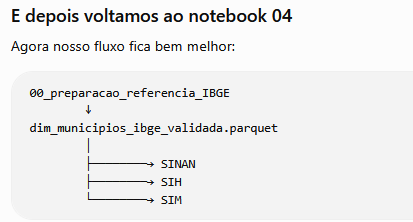